In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Neural network model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## Load and Inspect Dataset

In [4]:
# Load dataset from URL
df = pd.read_csv(
    'https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv'
)

# Preview dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Explore Dataset

In [5]:
# Dataset shape
print("Dataset shape:")
print(df.shape)

# Column names and data types
print("\nDataset info:")
print(df.info())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical summary:")
display(df.describe())


Dataset shape:
(1338, 7)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Encode Categorical Features

In [6]:
# Convert categorical columns into numerical values
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

# Preview encoded dataset
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Split Features and Target

In [7]:
# Features (inputs)
X = df_encoded.drop('charges', axis=1)

# Target (output)
y = df_encoded['charges']

# Display shapes
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1338, 8)
Target shape: (1338,)


## Train-Test Split and Feature Scaling

In [8]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Training feature shape:", X_train_scaled.shape)
print("Testing feature shape:", X_test_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (1070, 8)
Testing feature shape: (268, 8)
Training target shape: (1070,)
Testing target shape: (268,)


## Build Baseline Neural Network Model 

In [9]:
# Define baseline neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile model for regression
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display model architecture
model.summary()

c:\Users\jesse\OneDrive\Documents\Tripleten projects\Neural_Network_Diabetes_Classification\ml-env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train Baseline Model

In [10]:
# Train the neural network
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 325458272.0000 - mae: 13518.2217 - val_loss: 310328000.0000 - val_mae: 12654.1377
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 325393888.0000 - mae: 13516.0957 - val_loss: 310252768.0000 - val_mae: 12651.5303
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 325284864.0000 - mae: 13512.4844 - val_loss: 310107616.0000 - val_mae: 12646.7666
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 325081888.0000 - mae: 13506.1982 - val_loss: 309860256.0000 - val_mae: 12639.0117
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 324750016.0000 - mae: 13496.1504 - val_loss: 309455360.0000 - val_mae: 12626.8135
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 324211744.0000 - mae: 13480.8711 - val_loss: 308851616.0000 - val_mae: 12609.1143
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 323430496.0000 - mae: 13458.5186 - val_loss: 307962048.0000 - val_mae: 12583.8232
Epoch 8/100
2

## Evaluate Model Performance

In [11]:
# Evaluate model on test data
test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 31966818.0
Test MAE: 4074.784423828125


## Predictions vs Actual Values

In [12]:
# Generate predictions
predictions = model.predict(X_test_scaled)

# Create comparison dataframe
results = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': predictions.flatten()
})

# Display first 10 predictions
results.head(10)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


,Actual Charges,Predicted Charges
0,9095.06825,6181.500488
1,5272.17580,7418.361816
2,29330.98315,37573.902344
3,9301.89355,9308.838867
4,33750.29180,24863.394531
5,4536.25900,11361.962891
6,2117.33885,3086.833496
7,14210.53595,17715.984375
8,3732.62510,2644.892090
9,10264.44210,10842.323242


## Training History Visualization 

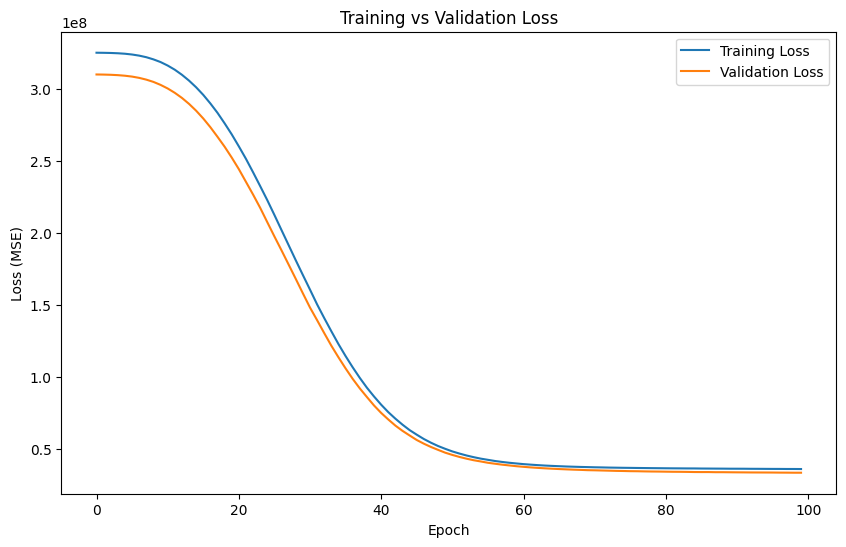

In [13]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.show()

## Predicted vs Actual Scatter Plot

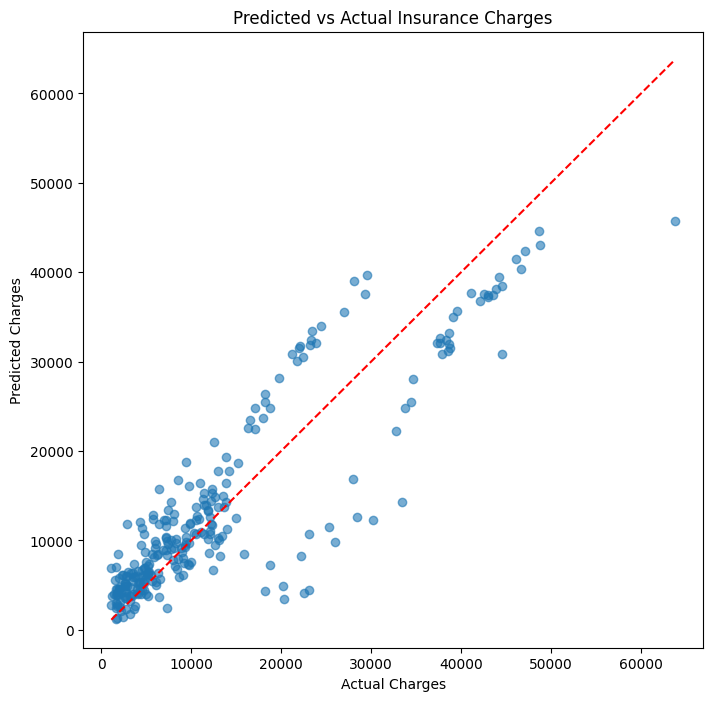

In [14]:
# Scatter plot of predictions vs actual values
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Predicted vs Actual Insurance Charges')

plt.show()

## Improved Neural Network Model

In [15]:
# Define improved neural network model
improved_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

# Compile improved model
improved_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Display model summary
improved_model.summary()

c:\Users\jesse\OneDrive\Documents\Tripleten projects\Neural_Network_Diabetes_Classification\ml-env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train Improved Model

In [16]:
# Train improved model
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 325428128.0000 - mae: 13517.1670 - val_loss: 310262784.0000 - val_mae: 12651.5068
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 325168032.0000 - mae: 13508.3438 - val_loss: 309788576.0000 - val_mae: 12634.5615
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 324129888.0000 - mae: 13474.3975 - val_loss: 308014208.0000 - val_mae: 12575.3564
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 320649184.0000 - mae: 13368.0068 - val_loss: 302783776.0000 - val_mae: 12408.2637
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 311709568.0000 - mae: 13098.6729 - val_loss: 290405536.0000 - val_mae: 12025.4570
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 292501728.0000 - mae: 12526.1504 - val_loss: 265939888.0000 - val_mae: 11266.6904
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 258123120.0000 - mae: 11468.5889 - val_loss: 224935056.0000 - val_mae: 9973.6748
Epoch 8/200
27

## Evaluate Improved Model

In [17]:
# Evaluate improved model
improved_test_loss, improved_test_mae = improved_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Improved Model Test Loss (MSE):", improved_test_loss)
print("Improved Model Test MAE:", improved_test_mae)

Improved Model Test Loss (MSE): 22127198.0
Improved Model Test MAE: 2955.574462890625


## Improved Model Training History

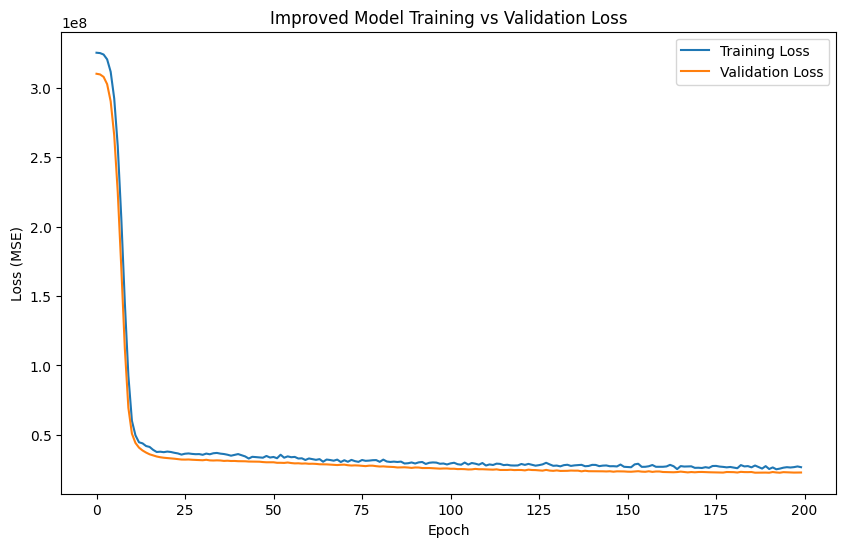

In [18]:
# Plot improved model training history
plt.figure(figsize=(10, 6))

plt.plot(improved_history.history['loss'], label='Training Loss')
plt.plot(improved_history.history['val_loss'], label='Validation Loss')

plt.title('Improved Model Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.show()

## Final Project Summary

## Project Overview

The goal of this project was to build a neural network capable of predicting medical insurance charges using demographic and health-related information. The dataset included features such as age, BMI, smoking status, number of children, sex, and region.

---

## Data Preprocessing

Several preprocessing steps were completed before training the neural network models:

- Loaded the insurance dataset using pandas
- Inspected the dataset structure and checked for missing values
- Encoded categorical variables using one-hot encoding
- Split the dataset into training and testing sets
- Applied feature scaling using StandardScaler

The dataset contained no missing values, which simplified preprocessing.

---

## Baseline Neural Network Model

The first model used a simple neural network architecture:

- Dense layer with 64 neurons
- Dense layer with 32 neurons
- Output layer with 1 neuron for regression

The model used:

- ReLU activation functions
- Mean Squared Error (MSE) loss
- Adam optimizer
- Mean Absolute Error (MAE) evaluation metric

### Baseline Model Results

- Test MAE: approximately 4074
- The model was able to learn general charge patterns but still produced noticeable prediction errors on larger insurance charges.

---

## Improved Neural Network Model

To improve performance, a more advanced neural network architecture was created with:

- Additional hidden layers
- Increased neurons
- Dropout layers for regularization
- More training epochs

Improved architecture:

- 128 neuron layer
- Dropout
- 64 neuron layer
- Dropout
- 32 neuron layer
- Output layer

### Improved Model Results

- Improved Test MAE: approximately 2955
- The improved model significantly outperformed the baseline model.

---

## Model Evaluation

The improved model showed:

- Lower validation loss
- Better prediction accuracy
- Reduced prediction error
- More stable learning curves

The training and validation loss curves remained close together throughout training, indicating minimal overfitting.

The scatter plot comparing predicted vs actual values showed that many predictions followed the diagonal trend line closely, although larger insurance charges remained more difficult to predict accurately.

---

## Key Insights

Several features appeared highly influential in predicting insurance charges:

- Smoking status
- BMI
- Age

Smokers generally had much higher predicted insurance costs than non-smokers.

---

## Future Improvements

If more time were available, several improvements could be explored:

- Hyperparameter tuning
- Learning rate optimization
- Feature engineering
- Cross-validation
- Testing alternative architectures
- Trying ensemble or boosting models

---

## Conclusion

This project successfully demonstrated the full machine learning workflow for a neural network regression problem:

- Data preprocessing
- Feature engineering
- Neural network construction
- Model training
- Performance evaluation
- Visualization and analysis

The improved neural network produced substantially better performance than the baseline model and demonstrated the effectiveness of deeper architectures and regularization techniques.